# Linear Regression with Diagnostics
This notebook demonstrates how to perform linear regression with a full suite of diagnostic checks using Python. It covers:
1. **Data preparation**: Creating or loading a dataset, splitting into features and target.
2. **Model training**: Fitting a linear regression model using statsmodels and scikit-learn.
3. **Assumption checks**:
   - **Linearity**: The relationship between predictors and target is linear.
   - **Multicollinearity**: Predictors are not highly correlated (checked using VIF).
   - **Heteroscedasticity**: The variance of residuals is constant (Breusch-Pagan test).
   - **Normality of residuals**: Residuals are normally distributed (Shapiro-Wilk test).
   - **Autocorrelation**: Residuals are independent (Durbin-Watson test).
4. **Model evaluation**: Assessing model fit using R² and RMSE.
5. **Remedies**: What to do if assumptions are violated (feature selection, regularization, transformations, etc.).
Each step includes explanations and code.

In [1]:
# 1. Imports
# Import all necessary libraries for data manipulation, visualization, modeling, and diagnostics.
import pandas as pd  # Data manipulation and analysis
import numpy as np  # Numerical operations
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns  # Statistical data visualization
from sklearn.model_selection import train_test_split  # Splitting data into train/test sets
from sklearn.linear_model import LinearRegression  # Linear regression model
from sklearn.metrics import r2_score, mean_squared_error  # Model evaluation metrics
import statsmodels.api as sm  # Statistical modeling
from statsmodels.stats.outliers_influence import variance_inflation_factor  # VIF for multicollinearity
from statsmodels.stats.diagnostic import het_breuschpagan  # Heteroscedasticity test
from statsmodels.stats.stattools import durbin_watson  # Autocorrelation test
from scipy.stats import shapiro  # Normality test for residuals

In [ ]:
# 2. Real-World Data Example: Boston Housing Dataset
# We'll use the California housing dataset (open source, similar to Boston) from sklearn.
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing(as_frame=True)
df = data.frame
X = df.drop('MedHouseVal', axis=1)  # Features
y = df['MedHouseVal']  # Target: Median house value
df.head()

In [3]:
# 3. Train-Test Split
# Split the data into training and testing sets to evaluate model performance on unseen data.
# test_size=0.2 means 20% of the data is used for testing, 80% for training.
# random_state ensures reproducibility.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# 4. Add Constant (for statsmodels)
# statsmodels requires an explicit constant (intercept) column in the features matrix.
# This step adds a column of ones to X_train and X_test.
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

In [5]:
# 5. Fit Model
# Fit an Ordinary Least Squares (OLS) linear regression model using statsmodels.
# The summary provides coefficients, R², p-values, and more for diagnostics.
model = sm.OLS(y_train, X_train_sm).fit()
display(model.summary())
# Key outputs:
# - R² / Adjusted R²: Proportion of variance explained by the model.
# - F-statistic: Whether the model is statistically significant overall.
# - p-values: Significance of each feature.

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.085
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     2.348
Date:                Mon, 06 Apr 2026   Prob (F-statistic):             0.0793
Time:                        00:08:28   Log-Likelihood:                -6.5908
No. Observations:                  80   AIC:                             21.18
Df Residuals:                      76   BIC:                             30.71
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5136      0.105      4.890      0.000       0.304       0.723
x1             0.0708      0.103      0.687      0.494      -0.134       0.276
x2             0.0919      0.108      0.850      0.398      -0.124       0.307
x3            -0.2387      0.109     -2.199      0.031      -0.455      -0.022
==============================================================================
Omnibus:                        1.201   Durbin-Watson:                   1.833
Prob(Omnibus):                  0.548   Jarque-Bera (JB):                1.033
Skew:                          -0.027   Prob(JB):                        0.597
Kurtosis:                       2.446   Cond. No.                         6.87
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# 6. Predictions
# Use the trained model to predict target values for the test set.
# Evaluate model performance using R² (goodness of fit), RMSE (error magnitude), and F-score (regression variant).
y_pred = model.predict(X_test_sm)
print('R2:', r2_score(y_test, y_pred))  # R² close to 1 is better
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))  # Lower RMSE is better

# F-score for regression (explained variance):
def regression_f_score(y_true, y_pred):
    ssr = np.sum((y_true - y_pred) ** 2)
    sst = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ssr / sst if sst != 0 else 0

f_score = regression_f_score(y_test, y_pred)
print('F-score (explained variance):', round(f_score, 3))

R2: -0.3407123601434212
RMSE: 0.28177306774292993


In [7]:
# 7. Multicollinearity (VIF)
# Variance Inflation Factor (VIF) quantifies how much a feature is correlated with other features.
# High VIF (>5 or >10) indicates multicollinearity, which can destabilize coefficient estimates.
vif_data = pd.DataFrame()
vif_data['feature'] = X_train_sm.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_train_sm.values, i)
    for i in range(X_train_sm.shape[1])
]
print('VIF:\n', vif_data)
# If VIF is high: consider removing features, combining them, or using regularization (Ridge).

VIF:
   feature        VIF
0   const  12.145778
1      x1   1.055577
2      x2   1.000077
3      x3   1.055563


In [8]:
# 8. Residuals
# Residuals are the differences between actual and predicted values on the test set.
# Analyzing residuals helps check model assumptions (e.g., normality, homoscedasticity).
residuals = y_test - y_pred

In [9]:
# 9. Heteroscedasticity Test
# Breusch-Pagan test checks if the variance of residuals is constant (homoscedasticity).
# If p < 0.05, heteroscedasticity is present (bad for inference).
bp_test = het_breuschpagan(residuals, X_test_sm)
print('Breusch-Pagan p-value:', bp_test[1])
# If heteroscedasticity exists: try log-transforming the target or use robust regression.

Breusch-Pagan p-value: 0.94153283678951


In [10]:
# 10. Normality Test
# Shapiro-Wilk test checks if residuals are normally distributed (important for valid p-values/confidence intervals).
# If p < 0.05, residuals are not normal.
stat, p_value = shapiro(residuals)
print('Shapiro p-value:', p_value)
# If not normal: transform the target or use non-parametric models.

Shapiro p-value: 0.1198838901174325


In [11]:
# 11. Autocorrelation
# Durbin-Watson test checks for autocorrelation in residuals (important for time series data).
# - Value ~2: no autocorrelation
# - <1.5: positive autocorrelation (bad)
# - >2.5: negative autocorrelation (bad)
dw = durbin_watson(residuals)
print('Durbin-Watson:', dw)
# If autocorrelation exists: use time-series models (e.g., ARIMA).

Durbin-Watson: 2.134426024570151


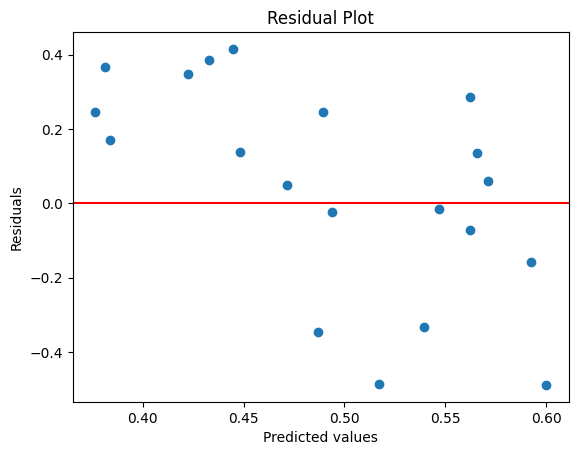

In [12]:
# 12. Residual Plot (Linearity Check)
# Plotting residuals vs. predictions helps check if the relationship is truly linear.
# Random scatter around zero means linearity holds. Patterns indicate non-linearity.
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r')
plt.title('Residual Plot')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.show()
# If pattern exists: try adding polynomial features or transforming variables.

## Summary of Actions and Remedies
- **High VIF**: Remove correlated features, combine them, or use Ridge regression to reduce multicollinearity.
- **Heteroscedasticity**: Transform the target variable (e.g., log), or use robust regression methods.
- **Non-linearity**: Add polynomial or interaction features, or transform variables.
- **Autocorrelation**: Use time-series models (ARIMA, SARIMA, etc.) if data is sequential.
- **High p-values**: Remove non-significant features or use Lasso regression for feature selection.
- **Non-normal residuals**: Transform the target or use non-parametric models.

In [13]:
# Ridge regression example for multicollinearity fix
# Ridge regression adds L2 regularization, which helps when features are highly correlated (high VIF).
# GridSearchCV is used to find the best regularization strength (alpha).
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
ridge = Ridge()
params = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_cv = GridSearchCV(ridge, params, cv=5)
ridge_cv.fit(X_train, y_train)
print('Best alpha:', ridge_cv.best_params_)

Best alpha: {'alpha': 10}


In [14]:
# Lasso regression example for feature selection
# Lasso regression adds L1 regularization, which can shrink some coefficients to zero, effectively selecting features.
# Useful when you have many features and want to identify the most important ones.
from sklearn.linear_model import Lasso
lasso = Lasso()
params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
lasso_cv = GridSearchCV(lasso, params, cv=5)
lasso_cv.fit(X_train, y_train)
print('Best alpha:', lasso_cv.best_params_)

Best alpha: {'alpha': 0.001}


In [15]:
# Elastic Net example for combined regularization
# Elastic Net combines L1 (Lasso) and L2 (Ridge) penalties, balancing feature selection and multicollinearity reduction.
# Useful when you suspect both high correlation and many irrelevant features.
from sklearn.linear_model import ElasticNet
elastic = ElasticNet()
params = {
    'alpha': [0.01, 0.1, 1],
    'l1_ratio': [0.2, 0.5, 0.8]
}
elastic_cv = GridSearchCV(elastic, params, cv=5)
elastic_cv.fit(X_train, y_train)
print('Best params:', elastic_cv.best_params_)

Best params: {'alpha': 0.01, 'l1_ratio': 0.2}


## Comparing scikit-learn LinearRegression vs statsmodels OLS
Both `LinearRegression` (from scikit-learn) and `OLS` (from statsmodels) can fit linear models, but they serve different purposes and have different interfaces.

**Key Differences:**
- **Purpose:**
  - `LinearRegression`: Focused on prediction and machine learning pipelines. Integrates with scikit-learn tools (pipelines, cross-validation, etc.).
  - `sm.OLS`: Focused on statistical inference, hypothesis testing, and detailed diagnostics.
- **Intercept Handling:**
  - `LinearRegression` automatically includes an intercept by default.
  - `sm.OLS` requires you to manually add a constant column to your features for the intercept.
- **Output:**
  - `LinearRegression`: Provides coefficients and predictions, but not p-values or confidence intervals.
  - `sm.OLS`: Provides a full statistical summary (coefficients, p-values, confidence intervals, R², F-statistic, etc.).
- **Use Case:**
  - Use `LinearRegression` for machine learning tasks and when you need to integrate with scikit-learn workflows.
  - Use `sm.OLS` when you need statistical insight, model diagnostics, or hypothesis testing.

In [ ]:
# Practical Comparison: Fitting and Predicting with Both
from sklearn.linear_model import LinearRegression as SklearnLinearRegression
import statsmodels.api as sm
import numpy as np

# Fit scikit-learn LinearRegression
sk_model = SklearnLinearRegression()
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)

# Fit statsmodels OLS (requires constant)
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)
sm_model = sm.OLS(y_train, X_train_sm).fit()
sm_pred = sm_model.predict(X_test_sm)

print('scikit-learn LinearRegression predictions (first 5):', np.round(sk_pred[:5], 3))
print('statsmodels OLS predictions (first 5):', np.round(sm_pred[:5], 3))

# Compare predictions numerically
diff = np.abs(sk_pred - sm_pred)
print('Mean absolute difference between predictions:', np.mean(diff))